In [5]:
import os
import torch
import librosa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from transformers import AutoModelForAudioClassification, AutoFeatureExtractor
from sklearn.metrics import recall_score, f1_score, accuracy_score, confusion_matrix
from tqdm import tqdm

# Load environment variables
ENV_PATH = Path().resolve().parents[0] / ".env"
load_dotenv(ENV_PATH)

def get_required_path(env_name):
    value = os.getenv(env_name)
    if not value:
        raise ValueError(f"[ERROR] {env_name} is not set in {ENV_PATH}")
    return Path(value).expanduser()

# Paths
DATAFRAMES_DIR = get_required_path("DATAFRAMES_DIR")
IEMOCAP_ROOT = get_required_path("IEMOCAP_ROOT_DIR")
BASE_CHECKPOINTS_DIR = get_required_path("CHECKPOINTS_DIR")
CHECKPOINT_DIR = get_required_path("CHECKPOINTS_DIR") / "wav2vec2_sentiment" 

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Point to your best model checkpoint
MODEL_BASE = "facebook/wav2vec2-base" # The architecture used during training

print(f"[INFO] Running inference on: {DEVICE}")

[INFO] Running inference on: cuda


In [9]:
# ==========================================
# 2. MODEL LOADING WITH WEIGHT SURGERY
# ==========================================
import torch
from transformers import Wav2Vec2Config, Wav2Vec2ForSequenceClassification

print(f"[INFO] Initializing standalone Feature Extractor from: {CHECKPOINT_DIR}")
feature_extractor = AutoFeatureExtractor.from_pretrained(str(CHECKPOINT_DIR))

# 1. Load configuration layout directly from your local checkpoint
config_path = CHECKPOINT_DIR / "config.json"
if config_path.exists():
    config = Wav2Vec2Config.from_pretrained(str(CHECKPOINT_DIR))
else:
    print(f"[WARNING] No config.json found in {CHECKPOINT_DIR}; using default 3-class configuration.")
    config = Wav2Vec2Config(num_labels=3)

# Force classification labels matching your pipeline inside the config
config.num_labels = 3
config.classifier_proj_size = 768
config.label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
config.id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}

# 2. Build empty architecture matching the standard sequence classification format
model = Wav2Vec2ForSequenceClassification(config)

# 3. Load the legacy raw bin weight file safely
bin_path = CHECKPOINT_DIR / "pytorch_model.bin"
if bin_path.exists():
    state_dict = torch.load(str(bin_path), map_location="cpu")
    print(f"[INFO] Successfully targeted pytorch_model.bin for weight surgery.")
else:
    raise FileNotFoundError(f"[ERROR] Cannot find pytorch_model.bin in {CHECKPOINT_DIR}!")

# 4. WEIGHT SURGERY: Strip custom wrappers to align with standard Wav2Vec2ForSequenceClassification
new_state_dict = {}
for key, value in state_dict.items():
    # Strip custom architecture nested wrapper prefix (e.g., 'base.wav2vec2...' -> 'wav2vec2...')
    if key.startswith("base.wav2vec2."):
        new_key = key.replace("base.wav2vec2.", "wav2vec2.")
        new_state_dict[new_key] = value
        
    # Handle standard base prefix conversions while dropping custom projectors
    elif key.startswith("base.") and not any(head in key for head in ["classifier", "projector"]):
        new_key = key.replace("base.", "")
        new_state_dict[new_key] = value
        
    # Map your old 'sent_head' weights directly to Hugging Face's standard 'classifier' head
    elif "sent_head.weight" in key:
        new_state_dict["classifier.weight"] = value
    elif "sent_head.bias" in key:
        new_state_dict["classifier.bias"] = value
        
    # Explicitly bypass evaluation heads to avoid mismatch crashes
    elif any(head in key for head in ["projector", "classifier"]):
        continue
        
    # Keep remaining standard root keys intact
    else:
        new_state_dict[key] = value

# 5. Load the surgically cleaned state dictionary into the model structure
msg = model.load_state_dict(new_state_dict, strict=False)
print(f"\n[INFO] Load surgery weights status:")
print(f" -> Missing Keys: {len(msg.missing_keys)} (Should only be classifier layers if any)")
print(f" -> Unexpected Keys: {len(msg.unexpected_keys)} (Should be 0 or very minimal)")

# Deploy to GPU/CPU
model.to(DEVICE)
model.eval()
print(f"\n[SUCCESS] Model successfully re-aligned and deployed to {DEVICE}")

[INFO] Initializing standalone Feature Extractor from: d:\Resfes\Project\Ser\checkpoints\wav2vec2_sentiment
[INFO] Successfully targeted pytorch_model.bin for weight surgery.

[INFO] Load surgery weights status:
 -> Missing Keys: 2 (Should only be classifier layers if any)
 -> Unexpected Keys: 0 (Should be 0 or very minimal)

[SUCCESS] Model successfully re-aligned and deployed to cuda


In [12]:
# ==========================================
# 3. INFERENCE PIPELINE
# ==========================================
# Load metadata
METADATA_PATH = DATAFRAMES_DIR / "iemocap_metadata.csv"
df = pd.read_csv(METADATA_PATH)

# Helper to build audio path
def get_audio_path(row):
    return IEMOCAP_ROOT / f"Session{row['Session']}" / "sentences" / "wav" / row['Dialog_ID'] / f"{row['Utterance_ID']}.wav"

df['path'] = df.apply(get_audio_path, axis=1)

# CRITICAL SAFETY CHECK: Filter out missing audio files to prevent mid-loop crashes
initial_count = len(df)
df = df[df['path'].apply(lambda p: p.exists())].reset_index(drop=True)
if len(df) < initial_count:
    print(f"[WARNING] Dropped {initial_count - len(df)} missing audio files.")

# Sentiment mapping
sentiment_map = {'hap': 2, 'exc': 2, 'neu': 1, 'sur': 1, 'ang': 0, 'sad': 0, 'fea': 0, 'fru': 0}
df = df[df["Raw_Emotion"].isin(sentiment_map.keys())].copy()
df["Label"] = df["Raw_Emotion"].map(sentiment_map)

# Inference Loop
all_preds = []
all_labels = []

print(f"[INFO] Starting inference on {len(df)} samples...")
with torch.no_grad():
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Cross-Corpus Inference"):
        # Load and preprocess audio (Cast Path object to str for safe librosa loading)
        audio, _ = librosa.load(str(row['path']), sr=16000)
        inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt", padding=True).to(DEVICE)
        
        # Inference
        logits = model(**inputs).logits
        pred = torch.argmax(logits, dim=1).item()
        
        all_preds.append(pred)
        all_labels.append(row['Label'])

print("[SUCCESS] Inference complete.")

[INFO] Starting inference on 7527 samples...


Cross-Corpus Inference: 100%|██████████| 7527/7527 [03:07<00:00, 40.22it/s]

[SUCCESS] Inference complete.



CROSS-CORPUS RESULTS
Accuracy : 0.5102
Macro F1 : 0.3356
UAR      : 0.3606


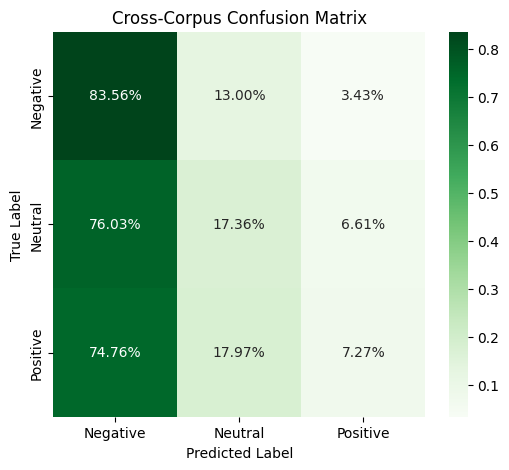

In [13]:
# Calculate metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")
uar = recall_score(all_labels, all_preds, average="macro")

print(f"\n{'='*30}")
print(f"CROSS-CORPUS RESULTS")
print(f"{'='*30}")
print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {f1:.4f}")
print(f"UAR      : {uar:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Greens", 
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title("Cross-Corpus Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()